<a href="https://colab.research.google.com/github/martinthuriaux/Grokking-Universality/blob/main/02_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load all these data

In [24]:
import torch, glob
!pip install transformer_lens
import numpy as np


from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/grokking_universality/runs"
files = sorted(glob.glob(f"{OUTPUT_DIR}/run_seed*.pt"))
records = []
for f in files:
    d = torch.load(f, map_location="cpu")
    records.append({
        "seed": d["seed"],
        "grokked": d["grokked"],
        "key_freqs": d["key_freqs"],
        "n_freqs": len(d["key_freqs"]),
        "grok_epoch": d["grok_epoch"],
        "weight_norm": d["weight_norm"],
        "final_test_acc": d["final_test_acc"],
    })

n_grokked = sum(r["grokked"] for r in records)
print(f"{len(records)} runs loaded, {n_grokked} grokked ({n_grokked/len(records):.0%})")

# keep only grokked models for the frequency analyses
G = [r for r in records if r["grokked"]]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
100 runs loaded, 100 grokked (100%)


**Hypothesis 1: Fourier structure is shared amongst all seeds** If grokked models use a common Fourier-clock solution, then they should display the same broad signatures even when they select different individual frequencies. For every grokked seed, we measure four quantities: accuracy over all p^2 input pairs, the fraction of embedding power contained in the detected key frequencies, the fraction of logit Fourier power consistent with dependence on a+b, and the fraction specifically carried by the model’s detected key frequencies. High values across seeds would provide broad evidence that the models share the same Fourier addition structure. This is a population-level screening test rather than a complete neuron-level or causal verification of every model.

In [25]:
import glob
import pandas as pd
import torch

from transformer_lens import HookedTransformer, HookedTransformerConfig

device = "cuda" if torch.cuda.is_available() else "cpu"


def build_model_from_record(record, device=device):
    """Reconstruct the exact architecture used in 01_seed_sweep.ipynb."""
    p = int(record["p"])

    cfg = HookedTransformerConfig(
        n_layers=1,
        d_model=128,
        d_mlp=512,
        n_heads=4,
        d_head=32,
        n_ctx=3,
        d_vocab=p + 1,
        act_fn="relu",
        normalization_type=None,
        seed=int(record["seed"]),
    )

    model = HookedTransformer(cfg).to(device)
    model.load_state_dict(record["state_dict"])
    model.eval()

    return model


def make_all_pairs(p, device=device):
    """Return every input [a, b, =] and its correct modular sum."""
    a = torch.arange(p, device=device).repeat_interleave(p)
    b = torch.arange(p, device=device).repeat(p)
    equals = torch.full_like(a, p)

    inputs = torch.stack([a, b, equals], dim=1)
    labels = (a + b) % p

    return inputs, labels


@torch.no_grad()
def broad_h1_metrics(model, p, key_freqs):
    inputs, labels = make_all_pairs(p, model.cfg.device)

    # ---------- Accuracy ----------
    logits = model(inputs)[:, -1, :]  # [p*p, d_vocab]
    predictions = logits.argmax(dim=-1)
    accuracy = (predictions == labels).float().mean().item()

    # ---------- Embedding frequency concentration ----------
    W_E = model.embed.W_E[:p]
    W_E = W_E - W_E.mean(dim=0, keepdim=True)

    embedding_power = (
        torch.fft.fft(W_E, dim=0).abs().pow(2).sum(dim=1)
    )
    embedding_power[0] = 0

    key_indices = sorted({
        index
        for frequency in key_freqs
        for index in (frequency % p, (-frequency) % p)
    })

    embedding_key_power_frac = (
        embedding_power[key_indices].sum()
        / embedding_power.sum().clamp_min(1e-12)
    ).item()

    # ---------- Does the output depend on a+b? ----------
    logits_grid = logits.reshape(p, p, -1)
    logits_grid = logits_grid - logits_grid.mean(
        dim=(0, 1), keepdim=True
    )

    logit_power = (
        torch.fft.fft2(logits_grid, dim=(0, 1))
        .abs()
        .pow(2)
        .sum(dim=-1)
    )  # [freq_a, freq_b]

    total_logit_power = logit_power.sum().clamp_min(1e-12)
    indices = torch.arange(p, device=logit_power.device)

    # A function of a+b has Fourier power at coordinates (k, k).
    sum_diag_frac = (
        logit_power[indices, indices].sum()
        / total_logit_power
    ).item()

    # Power specifically at this model's detected key frequencies.
    key_diag_frac = (
        logit_power[key_indices, key_indices].sum()
        / total_logit_power
    ).item()

    return {
        "accuracy_all_pairs": accuracy,
        "embedding_key_power_frac": embedding_key_power_frac,
        "sum_diag_frac": sum_diag_frac,
        "key_diag_frac": key_diag_frac,
    }

In [26]:
files = sorted(glob.glob(f"{OUTPUT_DIR}/run_seed*.pt"))

h1_rows = []

for path in files:
    record = torch.load(path, map_location="cpu")

    if not record["grokked"]:
        continue

    model = build_model_from_record(record)

    metrics = broad_h1_metrics(
        model=model,
        p=int(record["p"]),
        key_freqs=record["key_freqs"],
    )

    h1_rows.append({
        "seed": record["seed"],
        "key_freqs": tuple(record["key_freqs"]),
        "n_freqs": len(record["key_freqs"]),
        **metrics,
    })

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

h1_df = pd.DataFrame(h1_rows)
display(h1_df.head())

Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model to device:  cpu
Moving model t

,seed,key_freqs,n_freqs,accuracy_all_pairs,embedding_key_power_frac,sum_diag_frac,key_diag_frac
0,0,"(6, 8, 19)",3,1.000000,0.868124,0.920925,0.918426
1,1,"(3, 7, 26)",3,0.987540,0.954582,0.902295,0.898001
2,2,"(1, 20, 25)",3,1.000000,0.958951,0.906848,0.904566
3,3,"(5, 9, 13, 15)",4,0.997864,0.902953,0.884805,0.871407
4,4,"(4, 14, 26)",3,1.000000,0.956047,0.867316,0.865532


In [27]:
display(
    h1_df[
        [
            "accuracy_all_pairs",
            "embedding_key_power_frac",
            "sum_diag_frac",
            "key_diag_frac",
        ]
    ].describe(percentiles=[0.05, 0.50, 0.95])
)

print("\nModels with the weakest a+b structure:")
display(
    h1_df.nsmallest(10, "sum_diag_frac")[
        [
            "seed",
            "key_freqs",
            "accuracy_all_pairs",
            "sum_diag_frac",
            "key_diag_frac",
        ]
    ]
)

,accuracy_all_pairs,embedding_key_power_frac,sum_diag_frac,key_diag_frac
count,100.000000,100.000000,100.000000,100.000000
mean,0.997643,0.933341,0.901437,0.892639
std,0.003953,0.036145,0.099919,0.099855
min,0.979708,0.813611,0.367355,0.353746
5%,0.988928,0.861238,0.694050,0.688862
50%,0.999288,0.948322,0.932980,0.920560
95%,1.000000,0.964423,0.978765,0.972799
max,1.000000,0.971420,0.980252,0.974726



Models with the weakest a+b structure:


,seed,key_freqs,accuracy_all_pairs,sum_diag_frac,key_diag_frac
52,52,"(4, 13, 19, 20)",1.000000,0.367355,0.353746
98,98,"(1, 5, 9, 16)",0.979708,0.540008,0.538130
5,5,"(3, 11, 17, 21, 23)",0.998576,0.543403,0.541618
34,34,"(9, 24, 26)",0.998932,0.622537,0.608486
36,36,"(8, 12, 13, 22)",0.991100,0.670247,0.658359
64,64,"(1, 13, 16)",0.994304,0.695302,0.690468
46,46,"(14, 18, 20, 25)",0.998932,0.710510,0.701059
10,10,"(3, 7, 8, 22)",0.997152,0.785096,0.781997
24,24,"(5, 13, 16, 20)",0.988964,0.816820,0.796500
40,40,"(1, 11, 15, 19)",1.000000,0.833940,0.832390


Across the 100 grokked models, **average accuracy over all possible input pairs was approximately 99.8%**, confirming that the models successfully learned modular addition. On average, about **93.3% of the embedding Fourier power was concentrated in each model’s detected key frequencies**, suggesting that the number embeddings are largely organised around a small collection of Fourier clocks.

Approximately **90.1% of the logit Fourier power lay on the k_a=k_b diagonal**. Since equal frequencies in a and b combine as k(a+b), this indicates that the models’ outputs are primarily organised around the sum a+b. **About 89.3% of all logit power was located specifically at the detected key frequencies** on this diagonal, meaning that almost all of the observed sum structure was accounted for by the frequencies identified in the embeddings.

Most models showed a strong Fourier signature, although a small number of lower-scoring seeds reduced the averages. Overall, the results support H1 at the population level: the grokked models generally use the same broad Fourier-based structure to represent and calculate modular addition, even though this screening does not prove that every model contains an identical neuron-level circuit.

**Hypothesis 2: The chosen frequencies vary across seeds**

H1 asks whether the models share the same broad Fourier-based algorithm. H2 asks whether they implement that algorithm using the same specific frequencies. If random initialisation breaks the symmetry between otherwise equivalent solutions, different seeds should select different subsets of frequencies. We therefore treat each model’s set of detected key frequencies as its frequency signature and compare these signatures across the seed sweep. We measure how many distinct signatures occur, how often two models have exactly the same signature, and how much the signatures overlap. H2 is supported when models solve the same task using several different frequency signatures. This tests the project plan’s claim that the high-level mechanism is shared while the specific frequencies vary with initialisation.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

h2_df = h1_df[["seed", "key_freqs"]].copy()

# Convert each frequency list into a sorted tuple.
# Tuples are hashable, so pandas can count repeated signatures.
h2_df["signature"] = h2_df["key_freqs"].apply(
    lambda frequencies: tuple(
        sorted(int(frequency) for frequency in frequencies)
    )
)

h2_df["n_freqs"] = h2_df["signature"].apply(len)

display(h2_df.head())

,seed,key_freqs,signature,n_freqs
0,0,"(6, 8, 19)","(6, 8, 19)",3
1,1,"(3, 7, 26)","(3, 7, 26)",3
2,2,"(1, 20, 25)","(1, 20, 25)",3
3,3,"(5, 9, 13, 15)","(5, 9, 13, 15)",4
4,4,"(4, 14, 26)","(4, 14, 26)",3


In [29]:
signature_counts = (
    h2_df["signature"]
    .value_counts()
    .rename_axis("signature")
    .reset_index(name="n_models")
)

n_models = len(h2_df)
n_unique_signatures = h2_df["signature"].nunique()

modal_signature = signature_counts.iloc[0]["signature"]
modal_count = int(signature_counts.iloc[0]["n_models"])

print(f"Models analysed: {n_models}")
print(f"Unique frequency signatures: {n_unique_signatures}")
print(
    "Most common signature:",
    modal_signature,
    f"used by {modal_count}/{n_models} models "
    f"({modal_count / n_models:.1%})",
)

display(signature_counts.head(15))

Models analysed: 100
Unique frequency signatures: 99
Most common signature: (3, 13, 18) used by 2/100 models (2.0%)


,signature,n_models
0,"(3, 13, 18)",2
1,"(3, 7, 26)",1
2,"(6, 8, 19)",1
3,"(5, 9, 13, 15)",1
4,"(4, 14, 26)",1
5,"(3, 11, 17, 21, 23)",1
6,"(2, 8, 20)",1
7,"(5, 12, 15)",1
8,"(5, 8, 19)",1
9,"(14, 15, 16, 21)",1


We can check whether the frequencies overlap using the Jaccard Similarity

In [30]:
signatures = [
    set(signature)
    for signature in h2_df["signature"]
]

pairwise_rows = []

for i, j in combinations(range(n_models), 2):
    signature_i = signatures[i]
    signature_j = signatures[j]

    union = signature_i | signature_j
    intersection = signature_i & signature_j

    jaccard = (
        len(intersection) / len(union)
        if len(union) > 0
        else 1.0
    )

    pairwise_rows.append(
        {
            "seed_a": int(h2_df.iloc[i]["seed"]),
            "seed_b": int(h2_df.iloc[j]["seed"]),
            "exact_match": signature_i == signature_j,
            "jaccard_similarity": jaccard,
            "n_shared": len(intersection),
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)

exact_match_rate = pairwise_df["exact_match"].mean()
median_jaccard = pairwise_df["jaccard_similarity"].median()
mean_jaccard = pairwise_df["jaccard_similarity"].mean()

print(
    f"Pairs with identical signatures: "
    f"{exact_match_rate:.3%}"
)
print(
    f"Median pairwise Jaccard similarity: "
    f"{median_jaccard:.3f}"
)
print(
    f"Mean pairwise Jaccard similarity: "
    f"{mean_jaccard:.3f}"
)

Pairs with identical signatures: 0.020%
Median pairwise Jaccard similarity: 0.000
Mean pairwise Jaccard similarity: 0.080


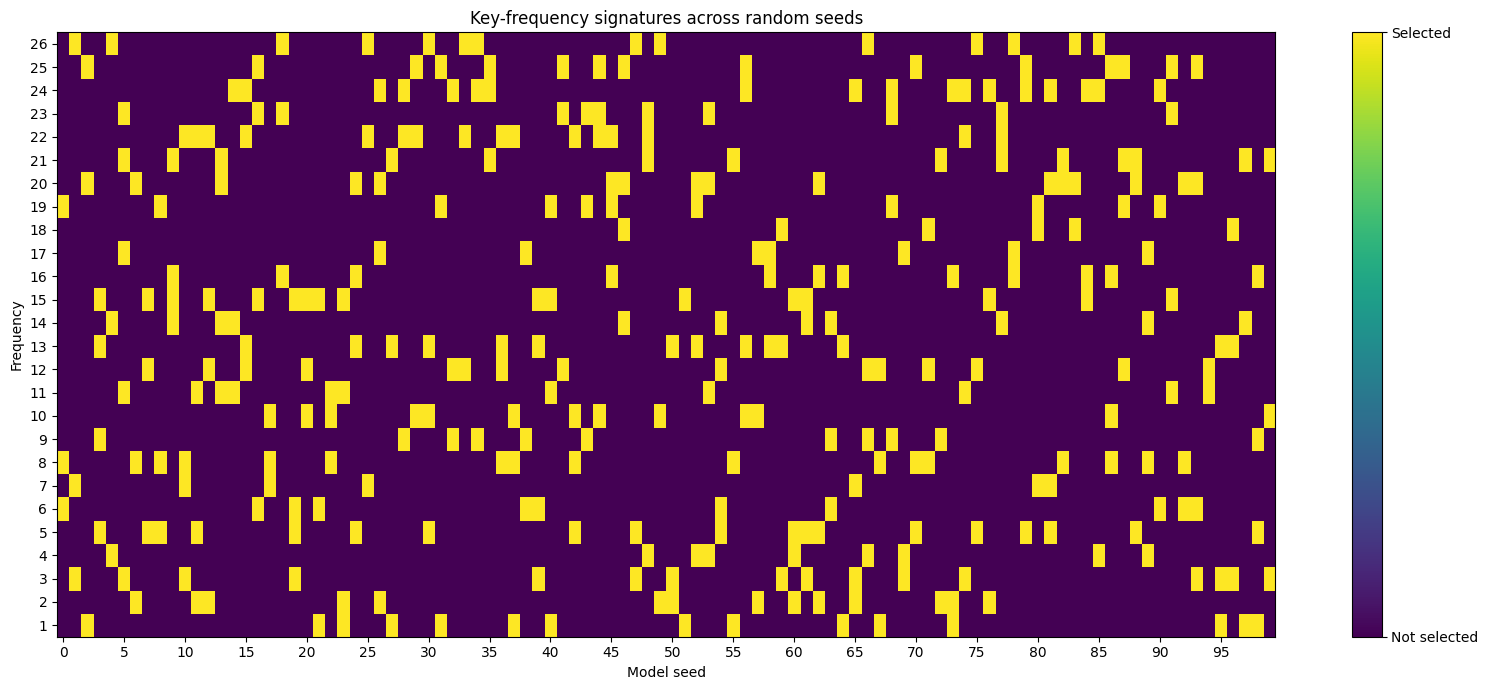

In [34]:
# Reload every run directly from disk.
plot_rows = []
p_values = set()

files = sorted(glob.glob(f"{OUTPUT_DIR}/run_seed*.pt"))

for path in files:
    try:
        record = torch.load(path, map_location="cpu")
    except Exception as error:
        print(f"Skipping unreadable file {path}: {error}")
        continue

    if not record["grokked"]:
        continue

    signature = tuple(
        sorted(int(frequency) for frequency in record["key_freqs"])
    )

    plot_rows.append(
        {
            "seed": int(record["seed"]),
            "signature": signature,
        }
    )

    p_values.add(int(record["p"]))

if len(p_values) != 1:
    raise ValueError(
        f"Expected one modulus across all runs, found {p_values}"
    )

p = p_values.pop()

plot_df = (
    pd.DataFrame(plot_rows)
    .sort_values("seed")
    .reset_index(drop=True)
)

usable_frequencies = np.arange(1, p // 2 + 1)
seeds = plot_df["seed"].to_numpy()

# Rows = frequencies; columns = seeds.
presence = np.zeros(
    (len(usable_frequencies), len(plot_df)),
    dtype=int,
)

for column, signature in enumerate(plot_df["signature"]):
    for frequency in signature:
        if not 1 <= frequency <= p // 2:
            raise ValueError(
                f"Invalid frequency {frequency} in seed {seeds[column]}"
            )

        presence[frequency - 1, column] = 1

plt.figure(figsize=(16, 7))

plt.imshow(
    presence,
    aspect="auto",
    interpolation="nearest",
    origin="lower",
    vmin=0,
    vmax=1,
)

plt.xlabel("Model seed")
plt.ylabel("Frequency")
plt.title("Key-frequency signatures across random seeds")

seed_tick_step = 5
seed_tick_positions = np.arange(
    0,
    len(seeds),
    seed_tick_step,
)

plt.xticks(
    ticks=seed_tick_positions,
    labels=seeds[seed_tick_positions],
)

plt.yticks(
    ticks=np.arange(len(usable_frequencies)),
    labels=usable_frequencies,
)

colorbar = plt.colorbar()
colorbar.set_ticks([0, 1])
colorbar.set_ticklabels(["Not selected", "Selected"])

plt.tight_layout()
plt.show()

The frequency-level implementation varied substantially across the seed sweep. Among 100 models, there were 99 distinct complete frequency signatures, with the most common signature appearing in only two models. Only one of the 4,950 model pairs had an identical signature, giving an exact-match rate of approximately 0.02%.

The median pairwise Jaccard similarity was zero, meaning that at least half of all model pairs shared no detected key frequencies. The mean similarity was only 0.08, showing that even when models did share frequencies, the overall overlap between their complete sets was generally small. The histogram and seed-frequency heatmap show the same pattern visually: different seeds select different combinations of Fourier clocks.

These results strongly support H2. Although the models generally share the broad Fourier-based structure identified in H1, their specific choice of frequencies is highly dependent on random initialisation. In other words, the models appear similar at the level of the overall algorithm but different at the level of its internal frequency implementation

**Hypothesis 3: The number of frequencies vary**:

We want to see if the models use a similar number of frequencies. For each grokked model, we count how many key frequencies are detected . A narrow distribution would suggest that the models usually require a similarly sized set of Fourier clocks, even when the identities of those clocks vary. A broad distribution would suggest that random initialisation also affects the complexity of the learned implementation.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Count the number of key frequencies in each model.
h3_df = h2_df[["seed", "signature"]].copy()
h3_df["n_freqs"] = h3_df["signature"].apply(len)

counts = h3_df["n_freqs"]

# Summary metrics
mean_count = counts.mean()
median_count = counts.median()
std_count = counts.std()
mode_count = counts.mode().iloc[0]
minimum_count = counts.min()
maximum_count = counts.max()

print(f"Models analysed: {len(h3_df)}")
print(f"Mean: {mean_count:.2f}")
print(f"Median: {median_count:.1f}")
print(f"Standard deviation: {std_count:.2f}")
print(f"Mode: {mode_count}")
print(f"Minimum: {minimum_count}")
print(f"Maximum: {maximum_count}")

# Distribution table
count_distribution = counts.value_counts().sort_index()

display(
    count_distribution
    .rename("Number of models")
    .to_frame()
)

Models analysed: 100
Mean: 3.42
Median: 3.0
Standard deviation: 0.55
Mode: 3
Minimum: 2
Maximum: 5


,Number of models
n_freqs,
2,2
3,55
4,42
5,1


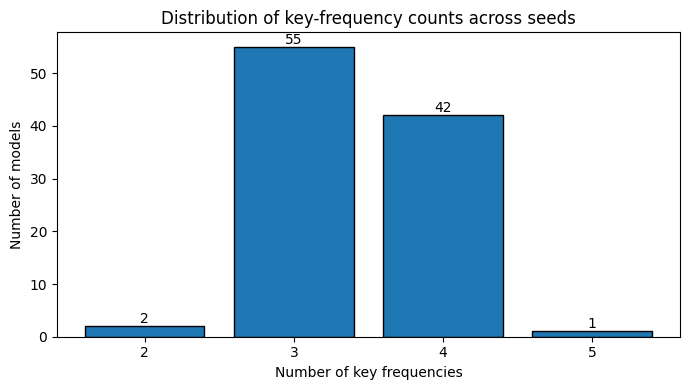

In [37]:
plt.figure(figsize=(7, 4))

bars = plt.bar(
    count_distribution.index,
    count_distribution.values,
    edgecolor="black",
)

plt.xlabel("Number of key frequencies")
plt.ylabel("Number of models")
plt.title("Distribution of key-frequency counts across seeds")
plt.xticks(count_distribution.index)

# Add the number of models above each bar.
for bar, value in zip(bars, count_distribution.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

The number of detected key frequencies is tightly concentrated across seeds. Of the 100 models, 55 used three frequencies and 42 used four, meaning that 97% of models fell into these two categories. Only two models were assigned two frequencies, and one model was assigned five. The mean count was 3.42, the median and mode were both 3, and the standard deviation was 0.55, indicating relatively little variation between seeds.

These counts should be interpreted as detector estimates rather than exact ground truth. The frequency detector classifies a frequency as key when its embedding Fourier power passes a chosen threshold, so frequencies close to that threshold may occasionally be included or excluded incorrectly. Establishing the exact set of frequencies with complete confidence would require a deeper mechanistic analysis of each model, including inspection of its activations and causal ablations. Therefore, the results provide strong evidence for a narrow three-to-four-frequency distribution, but not a guarantee that every individual count is perfectly classified.

**Hypothesis 4: Preference of frequencies**

We want to see if certain frequencies are preferred over others. We count how many models use each frequency and compare the observed counts against a uniform baseline in which every usable frequency is equally likely to be selected. If the observed distribution differs significantly from this baseline, this suggests that the architecture or training process systematically prefers some Fourier frequencies and avoids others.

In [38]:
usable_frequencies = np.arange(1, p // 2 + 1)

n_models = len(h2_df)
n_usable = len(usable_frequencies)

frequency_counts = np.zeros(n_usable, dtype=int)

for signature in h2_df["signature"]:
    for frequency in signature:
        frequency_counts[int(frequency) - 1] += 1

frequency_usage = pd.DataFrame({
    "frequency": usable_frequencies,
    "n_models": frequency_counts,
})

frequency_usage["percentage_models"] = (
    100 * frequency_usage["n_models"] / n_models
)

total_selections = frequency_counts.sum()

# Expected count if all frequencies were equally likely.
expected_count = total_selections / n_usable
expected_percentage = 100 * expected_count / n_models

print(f"Models analysed: {n_models}")
print(f"Total frequency selections: {total_selections}")
print(f"Usable frequencies: {n_usable}")
print(f"Uniform expected count per frequency: {expected_count:.2f}")
print(
    f"Uniform expected percentage of models: "
    f"{expected_percentage:.1f}%"
)

display(
    frequency_usage.sort_values(
        "n_models",
        ascending=False,
    )
)

Models analysed: 100
Total frequency selections: 342
Usable frequencies: 26
Uniform expected count per frequency: 13.15
Uniform expected percentage of models: 13.2%


,frequency,n_models,percentage_models
4,5,19,19.0
23,24,18,18.0
14,15,17,17.0
7,8,17,17.0
2,3,16,16.0
19,20,16,16.0
21,22,16,16.0
0,1,15,15.0
11,12,15,15.0
24,25,15,15.0


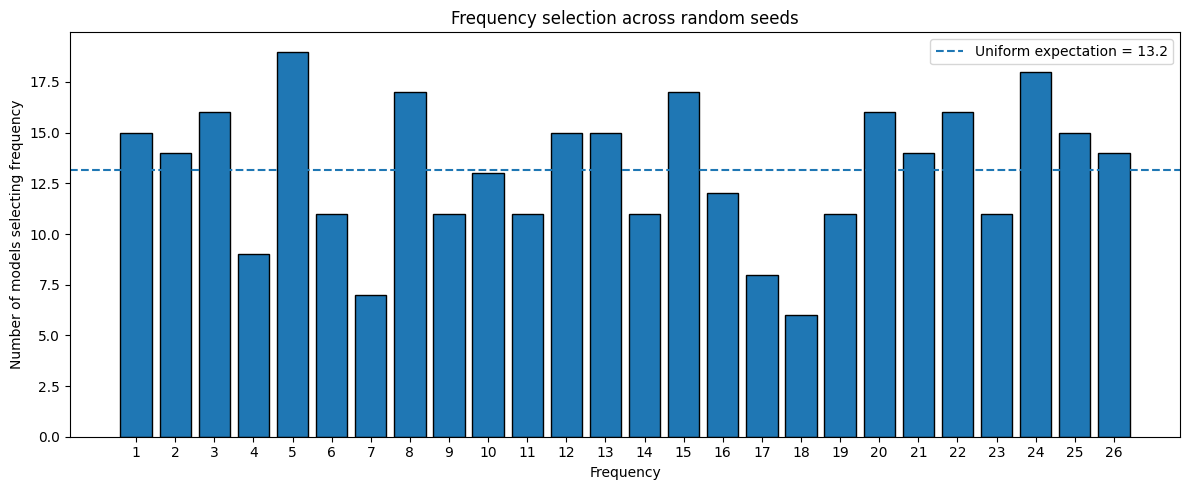

In [39]:
plt.figure(figsize=(12, 5))

bars = plt.bar(
    frequency_usage["frequency"],
    frequency_usage["n_models"],
    edgecolor="black",
)

plt.axhline(
    expected_count,
    linestyle="--",
    label=f"Uniform expectation = {expected_count:.1f}",
)

plt.xlabel("Frequency")
plt.ylabel("Number of models selecting frequency")
plt.title("Frequency selection across random seeds")

plt.xticks(usable_frequencies)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
rng = np.random.default_rng(0)

n_permutations = 10_000

counts_per_model = (
    h2_df["signature"]
    .apply(len)
    .to_numpy()
)

null_counts = np.zeros(
    (n_permutations, n_usable),
    dtype=int,
)

for permutation in range(n_permutations):
    simulated_counts = np.zeros(
        n_usable,
        dtype=int,
    )

    for model_count in counts_per_model:
        chosen_indices = rng.choice(
            n_usable,
            size=model_count,
            replace=False,
        )

        simulated_counts[chosen_indices] += 1

    null_counts[permutation] = simulated_counts

In [41]:
null_expected = null_counts.mean(axis=0)

observed_statistic = np.sum(
    (frequency_counts - null_expected) ** 2
    / null_expected
)

null_statistics = np.sum(
    (null_counts - null_expected) ** 2
    / null_expected,
    axis=1,
)

p_value = (
    np.sum(null_statistics >= observed_statistic) + 1
) / (n_permutations + 1)

print(
    f"Observed non-uniformity statistic: "
    f"{observed_statistic:.2f}"
)
print(f"Permutation p-value: {p_value:.4f}")

Observed non-uniformity statistic: 21.94
Permutation p-value: 0.5035


In [42]:
null_std = null_counts.std(
    axis=0,
    ddof=1,
)

null_std = np.where(
    null_std == 0,
    1,
    null_std,
)

observed_z = (
    frequency_counts - null_expected
) / null_std

null_z = (
    null_counts - null_expected
) / null_std

# Maximum absolute deviation in every permutation.
max_absolute_null_z = np.max(
    np.abs(null_z),
    axis=1,
)

# Family-wise 5% cutoff.
significance_cutoff = np.percentile(
    max_absolute_null_z,
    95,
)

frequency_usage["expected_count"] = null_expected
frequency_usage["z_score"] = observed_z

frequency_usage["preference"] = np.where(
    observed_z > significance_cutoff,
    "Preferred",
    np.where(
        observed_z < -significance_cutoff,
        "Avoided",
        "No clear difference",
    ),
)

preferred_frequencies = frequency_usage.loc[
    frequency_usage["preference"] == "Preferred",
    "frequency",
].tolist()

avoided_frequencies = frequency_usage.loc[
    frequency_usage["preference"] == "Avoided",
    "frequency",
].tolist()

print(
    f"Multiple-comparison cutoff: "
    f"|z| > {significance_cutoff:.2f}"
)
print("Preferred frequencies:", preferred_frequencies)
print("Avoided frequencies:", avoided_frequencies)

display(
    frequency_usage.sort_values(
        "z_score",
        ascending=False,
    )
)

Multiple-comparison cutoff: |z| > 3.19
Preferred frequencies: []
Avoided frequencies: []


,frequency,n_models,percentage_models,expected_count,z_score,preference
4,5,19,19.0,13.1366,1.756749,No clear difference
23,24,18,18.0,13.1832,1.409699,No clear difference
7,8,17,17.0,13.1354,1.143442,No clear difference
14,15,17,17.0,13.1624,1.130596,No clear difference
2,3,16,16.0,13.1321,0.851726,No clear difference
21,22,16,16.0,13.1583,0.834971,No clear difference
19,20,16,16.0,13.1762,0.831389,No clear difference
24,25,15,15.0,13.1279,0.554983,No clear difference
0,1,15,15.0,13.1357,0.547754,No clear difference
12,13,15,15.0,13.1671,0.539043,No clear difference


The observed frequency counts varied across the seed sweep, with some frequencies appearing more often than others. However, the overall permutation test produced a p-value of 0.5035, meaning that approximately half of the uniformly random simulations produced a distribution at least as uneven as the observed one. The apparent variation is therefore consistent with random selection.

After correcting for comparisons across all 26 frequencies, no individual frequency was classified as significantly preferred or avoided. The strongest positive and negative deviations remained below the required multiple-comparison threshold. We therefore find no statistically significant support for Hypothesis 4 in this experiment: the specific frequencies appear approximately uniformly selected across random seeds.

This should not be interpreted as proof of perfect uniformity. Subtle preferences may require more models to detect, and the results depend on an automated frequency detector that can occasionally include or exclude borderline frequencies. Exact verification would require deeper model-level analysis.

**Hypothesis 5: Frequencies are correlated to grokking speed**

We check whether differences in the learned Fourier implementation are related to how quickly a model groks. We test whether the number of key frequencies is associated with grokking speed and final weight norm, We use Spearman correlation for frequency count because the count is discrete and the relationship may not be linear. In addition, final weight norm should not be interpreted as a direct measure of loss-landscape flatness.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Saved grokked-model records
run_df = pd.DataFrame(G)

# The modulus used in this experiment
p = 53

# Combine frequency information with training information
h5_df = h3_df[
    ["seed", "signature", "n_freqs"]
].merge(
    run_df[
        ["seed", "grok_epoch", "weight_norm"]
    ],
    on="seed",
    how="inner",
)

h5_df = (
    h5_df
    .dropna(
        subset=[
            "n_freqs",
            "grok_epoch",
            "weight_norm",
        ]
    )
    .reset_index(drop=True)
)

print(f"Models analysed: {len(h5_df)}")
display(h5_df.head())

Models analysed: 100


,seed,signature,n_freqs,grok_epoch,weight_norm
0,0,"(6, 8, 19)",3,9200,29.783472
1,1,"(3, 7, 26)",3,8200,30.159521
2,2,"(1, 20, 25)",3,6000,25.587797
3,3,"(5, 9, 13, 15)",4,5000,32.282204
4,4,"(4, 14, 26)",3,2600,26.433958


In [48]:
rho_grok, p_grok = spearmanr(
    h5_df["n_freqs"],
    h5_df["grok_epoch"],
)

print("Frequency count versus grok epoch")
print(f"Spearman rho: {rho_grok:.3f}")
print(f"p-value: {p_grok:.4f}")

Frequency count versus grok epoch
Spearman rho: 0.091
p-value: 0.3685


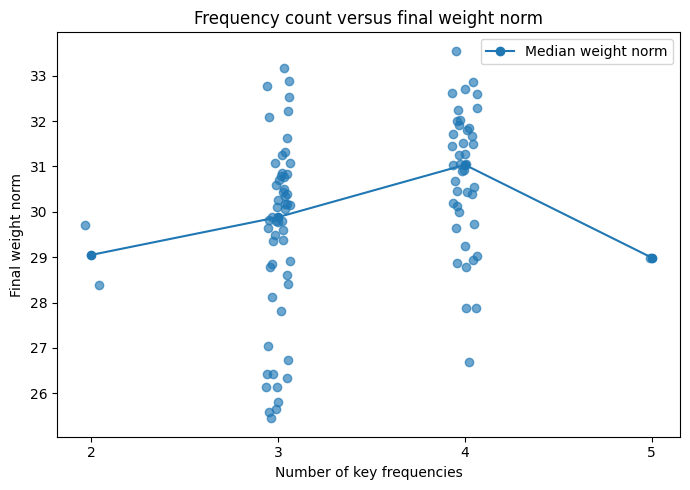

In [49]:
rng = np.random.default_rng(1)

x_jittered = (
    h5_df["n_freqs"].to_numpy()
    + rng.uniform(-0.07, 0.07, len(h5_df))
)

median_norm = (
    h5_df
    .groupby("n_freqs")["weight_norm"]
    .median()
    .sort_index()
)

plt.figure(figsize=(7, 5))

plt.scatter(
    x_jittered,
    h5_df["weight_norm"],
    alpha=0.65,
)

plt.plot(
    median_norm.index,
    median_norm.values,
    marker="o",
    label="Median weight norm",
)

plt.xlabel("Number of key frequencies")
plt.ylabel("Final weight norm")
plt.title("Frequency count versus final weight norm")
plt.xticks(sorted(h5_df["n_freqs"].unique()))
plt.legend()
plt.tight_layout()
plt.show()

The number of detected key frequencies was not significantly associated with grokking speed. The Spearman correlation was very small and positive (ρ=0.091), with a p-value of 0.3685. This means that models using more frequencies did not consistently grok earlier or later than models using fewer frequencies.

The final weight-norm plot also shows no obvious consistent relationship. Models with four frequencies have a slightly higher median weight norm than models with three, but the two groups overlap substantially. The estimates for two- and five-frequency models are especially uncertain because those categories contain very few models. The pattern is therefore descriptive and should not be interpreted as strong evidence of an association without a corresponding statistical test.

Overall, the current results do not support H5: frequency count does not appear to be a useful predictor of grokking speed, and there is no clear visual relationship with final weight norm. These conclusions concern the number of detected frequencies, rather than which particular frequencies were selected. They are also subject to uncertainty from the automated frequency detector. Finally, weight norm is not a direct measurement of loss-landscape flatness, so this analysis cannot establish a relationship between frequency structure and flatness.